In [ ]:
# import library
import pandas as pd  #olah data (DataFrame)
import numpy as np  #hitungan numerik
import matplotlib.pyplot as plt  #visualisasi grafik
from sklearn.model_selection import train_test_split  #membagi data training dan testing
from sklearn.linear_model import LogisticRegression  #klasifikasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  #evaluasi model

In [ ]:
# dataset
data = {
    'iklan': [1,2,3,4,5,6,7,8,9,10],
    'diskon': [5,10,15,20,25,30,35,40,45,50],
    'rating': [3.0,3.2,3.4,3.6,3.8,4.0,4.2,4.4,4.6,4.8],
    'laku': [0,0,0,0,1,1,1,1,1,1]
}

df = pd.DataFrame(data)
print(df)

   iklan  diskon  rating  laku
0      1       5     3.0     0
1      2      10     3.2     0
2      3      15     3.4     0
3      4      20     3.6     0
4      5      25     3.8     1
5      6      30     4.0     1
6      7      35     4.2     1
7      8      40     4.4     1
8      9      45     4.6     1
9     10      50     4.8     1


In [ ]:
X = df[['iklan', 'diskon', 'rating']] #variabel independen (input)
y = df['laku'] #variabel dependen (output)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data dibagi menjadi:

- 80% training

- 20% testing

random_state=42 agar hasil konsisten

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# melihat koefisien
print("Intercept (a):", model.intercept_)
print("Koefisien (b):", model.coef_[0])

Intercept (a): [-16.95130831]
Koefisien: [0.14398524 0.71992621 0.02849152]


In [ ]:
y_pred = model.predict(X_test) #prediksi data testing

print("Data Testing:")
print(X_test)
print("Aktual:", y_test.values)
print("Prediksi:", y_pred)

Data Testing:
   iklan  diskon  rating
8      9      45     4.6
1      2      10     3.2
Aktual: [1 0]
Prediksi: [1 0]


In [ ]:
# evaluasi
print("\nAkurasi:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Akurasi: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [ ]:
# prediksi
prediksi = model.predict([[5, 25, 4.0]])

print("Prediksi (0=tidak laku, 1=laku):", prediksi[0])

Prediksi (0=tidak laku, 1=laku): 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


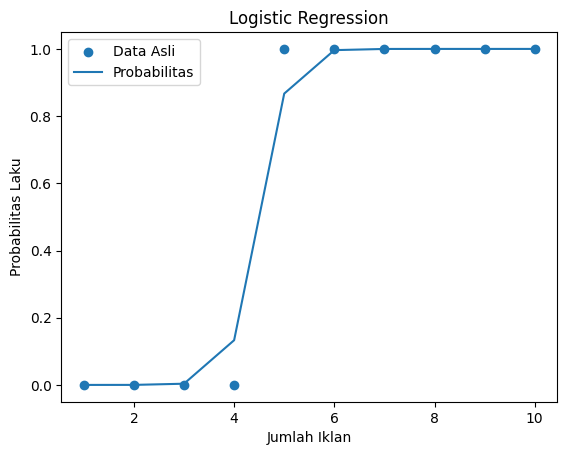

In [ ]:
plt.scatter(df['iklan'], df['laku'], label="Data Asli") #menampilkan data asli dalam bentuk titik
plt.plot(df['iklan'], model.predict_proba(X)[:,1], label="Probabilitas") #menampilkan garis hasil model regresi

plt.xlabel("Jumlah Iklan")
plt.ylabel("Probabilitas Laku")
plt.title("Logistic Regression")
plt.legend()
plt.show()

Hasil analisis menunjukkan bahwa iklan, diskon, dan rating berpengaruh terhadap kemungkinan produk laku. Semakin tinggi nilainya maka peluang laku akan meningkat. Model juga mampu memprediksi data testing dengan cukup baik, terlihat dari hasil prediksi yang mendekati nilai aktual. Namun, karena data yang digunakan masih sederhana, hasilnya belum sepenuhnya mencerminkan kondisi nyata.